In [ ]:
import pandas as pd

# Load the parquet file
df = pd.read_parquet('/content/data.parquet')

# Print the column names
print(df.columns)
print(df.head)

Index(['banknifty', 'nifty', 'tte'], dtype='object')
<bound method NDFrame.head of                      banknifty     nifty  tte
time                                         
2021-01-01 09:15:00   0.286058  0.199729   27
2021-01-01 09:16:00   0.285381  0.200433   27
2021-01-01 09:17:00   0.284233  0.200004   27
2021-01-01 09:18:00   0.286104  0.199860   27
2021-01-01 09:19:00   0.285539  0.198951   27
...                        ...       ...  ...
2022-06-30 15:26:00   0.240701  0.214758   28
2022-06-30 15:27:00   0.240875  0.216558   28
2022-06-30 15:28:00   0.242115  0.216794   28
2022-06-30 15:29:00   0.243426  0.216455   28
2022-06-30 15:30:00   0.241907  0.216081   28

[690512 rows x 3 columns]>


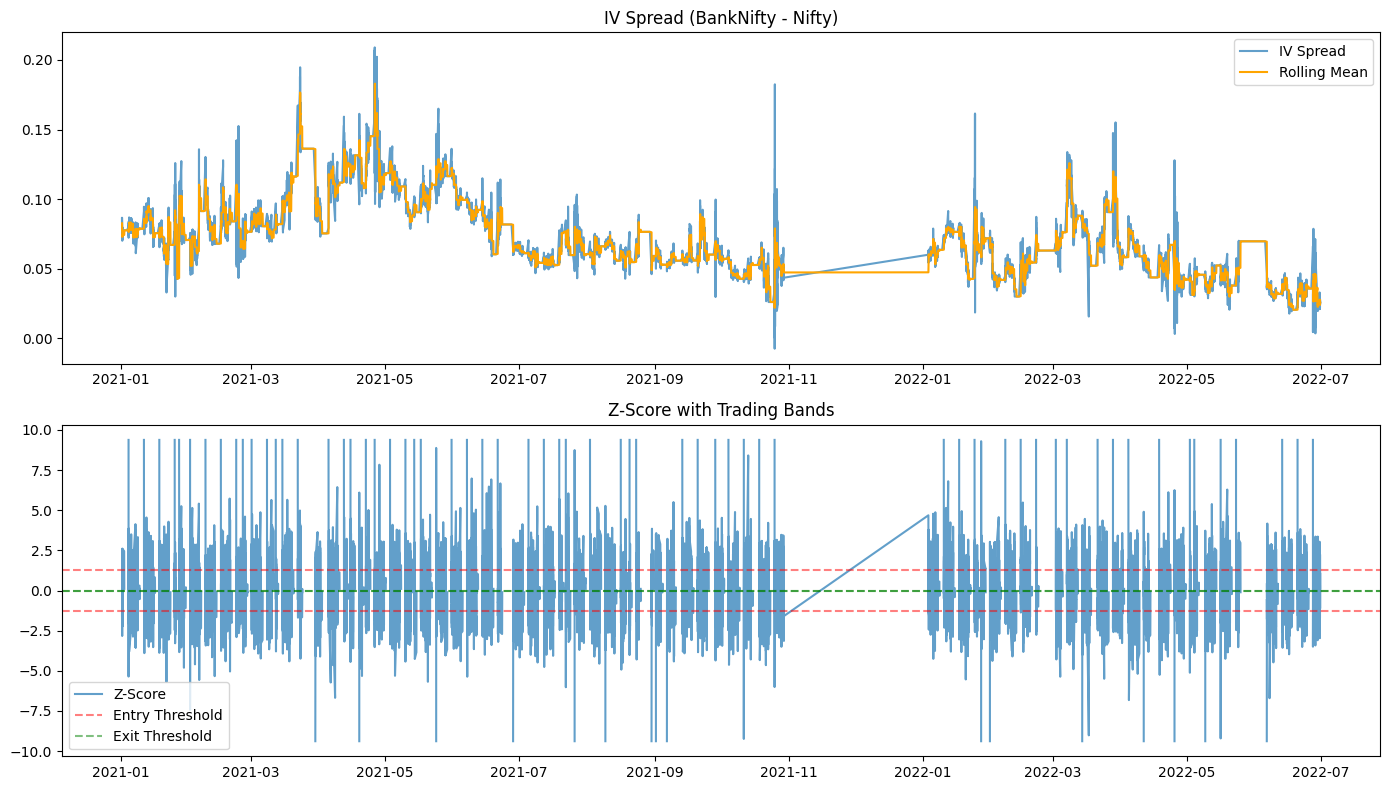

<ipython-input-1-d038a0a18bda>:110: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['signal'] = df['signal'].replace(to_replace=0, method='ffill').fillna(0)



=== Strategy Performance ===
Total Return: 131613.94
Annualized Return: 68770.28
Annualized Volatility: 2215.09
Sharpe Ratio: 31.05
Max Drawdown: 25552.43
Number of Trades: 646


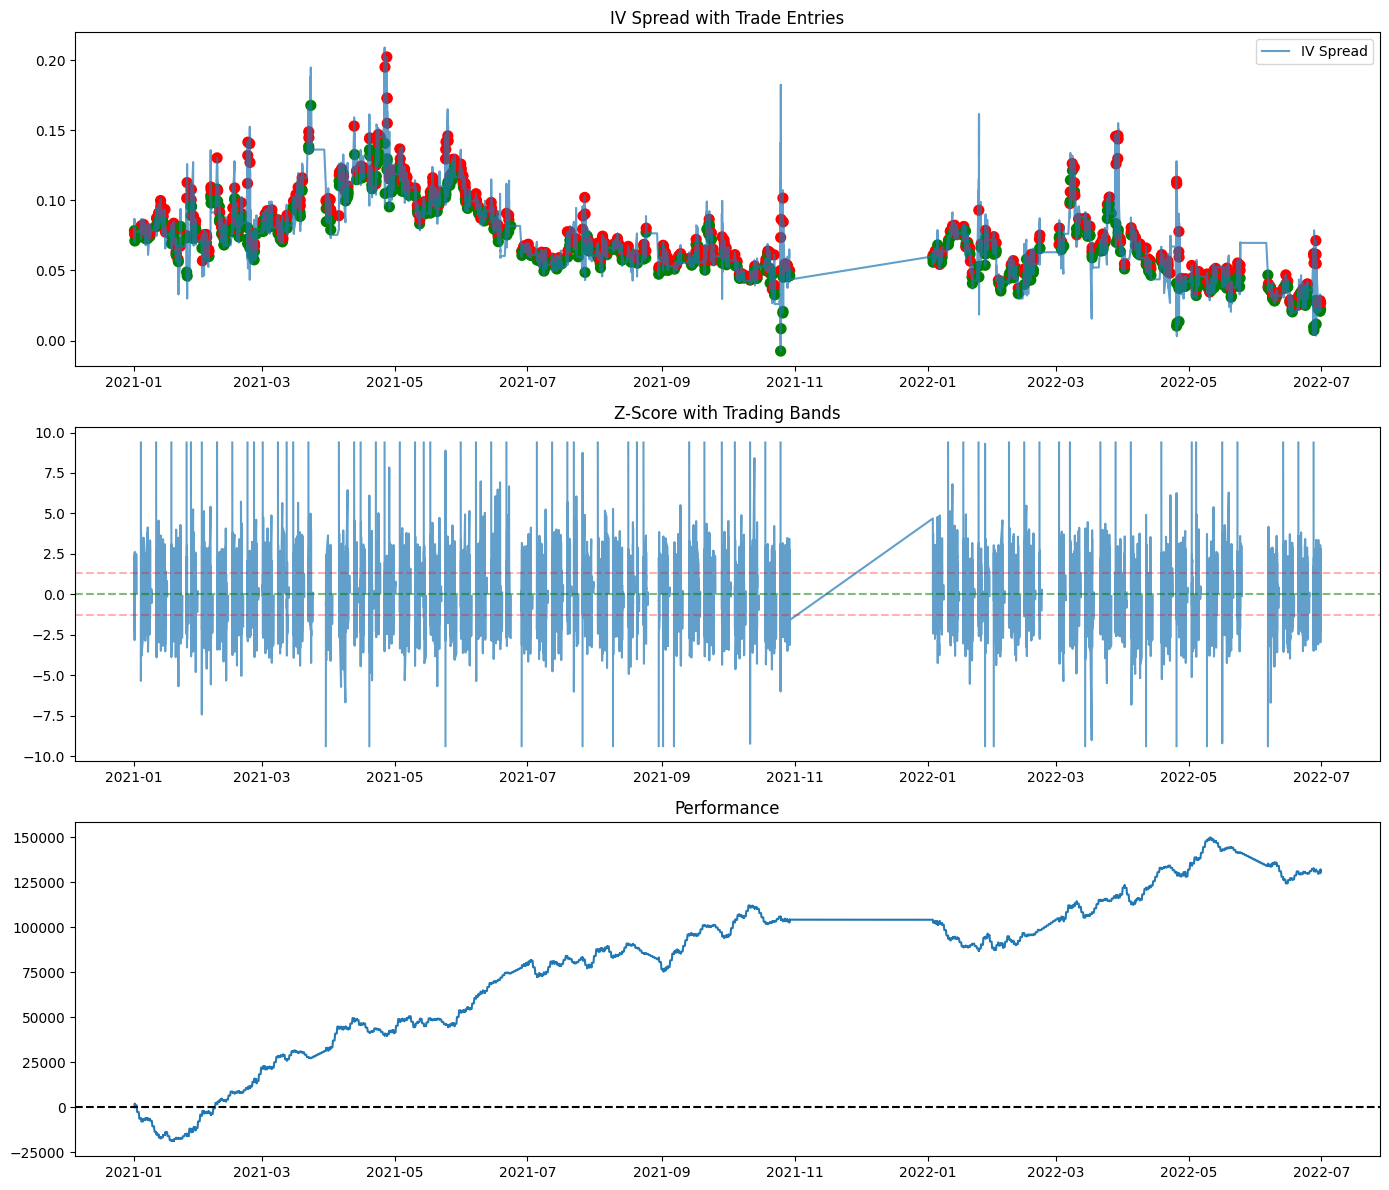

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import time, timedelta

class IVPairTradingStrategy:
    def __init__(self, lookback=375*3, z_entry=1.5, z_exit=0.5, tte_exponent=0.7,
                 min_holding=30, max_holding=375*5, trading_hours=(time(9,15), time(15,30))):
        self.lookback = lookback
        self.z_entry = z_entry
        self.z_exit = z_exit
        self.tte_exponent = tte_exponent
        self.min_holding = min_holding
        self.max_holding = max_holding
        self.trading_hours = trading_hours
        self.data = None
        self.results = None

    def load_data(self, filepath):
        self.data = pd.read_parquet(filepath)

        if not isinstance(self.data.index, pd.DatetimeIndex):
            if 'datetime' in self.data.columns:
                self.data.set_index('datetime', inplace=True)
            else:
                raise ValueError("Data must have datetime index or column")

        self.data = self.data.between_time(*self.trading_hours).sort_index()
        self.data[['banknifty', 'nifty', 'tte']] = self.data[['banknifty', 'nifty', 'tte']].ffill()
        self.data['iv_spread'] = self.data['banknifty'] - self.data['nifty']

        if self.data['iv_spread'].isna().any():
            raise ValueError("Spread calculation resulted in NA values")

    def calculate_zscores(self):
        min_periods = max(30, int(self.lookback * 0.1))
        self.data['spread_mean'] = self.data['iv_spread'].rolling(
            window=self.lookback, min_periods=min_periods).mean()
        self.data['spread_std'] = self.data['iv_spread'].rolling(
            window=self.lookback, min_periods=min_periods).std()
        self.data['z_score'] = (self.data['iv_spread'] - self.data['spread_mean']) / self.data['spread_std']

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))
        ax1.plot(self.data['iv_spread'], label='IV Spread', alpha=0.7)
        ax1.plot(self.data['spread_mean'], label='Rolling Mean', color='orange')
        ax1.set_title('IV Spread (BankNifty - Nifty)')
        ax1.legend()

        ax2.plot(self.data['z_score'], label='Z-Score', alpha=0.7)
        ax2.axhline(self.z_entry, color='r', linestyle='--', alpha=0.5, label='Entry Threshold')
        ax2.axhline(-self.z_entry, color='r', linestyle='--', alpha=0.5)
        ax2.axhline(self.z_exit, color='g', linestyle='--', alpha=0.5, label='Exit Threshold')
        ax2.axhline(-self.z_exit, color='g', linestyle='--', alpha=0.5)
        ax2.set_title('Z-Score with Trading Bands')
        ax2.legend()
        plt.tight_layout()
        plt.show()

    def generate_signals(self):
        df = self.data
        df['signal'] = 0
        df['entry_time'] = pd.NaT
        df['holding_period'] = 0.0

        in_trade = False
        entry_index = None
        entry_z = 0

        holding_counter = 0  # market time counter

        for i in range(1, len(df)):
            current_time = df.index[i]

            if in_trade:
                holding_counter += 1  # count market minutes
                df.at[current_time, 'holding_period'] = holding_counter

                current_z = df.at[current_time, 'z_score']
                exit_due_to_z = abs(current_z) <= self.z_exit
                exit_due_to_cross = (entry_z > 0 and current_z <= 0) or (entry_z < 0 and current_z >= 0)
                exit_due_to_max = holding_counter >= self.max_holding

                if holding_counter >= self.min_holding and (exit_due_to_z or exit_due_to_cross or exit_due_to_max):
                    in_trade = False
                    entry_index = None
                    entry_z = 0
                    holding_counter = 0  # reset counter
                    continue
                else:
                    df.at[current_time, 'signal'] = np.sign(entry_z) * -1
                    continue

            current_z = df.at[current_time, 'z_score']
            if current_z >= self.z_entry:
                df.at[current_time, 'signal'] = -1
                df.at[current_time, 'entry_time'] = current_time
                entry_z = current_z
                entry_index = current_time
                in_trade = True
                holding_counter = 0
            elif current_z <= -self.z_entry:
                df.at[current_time, 'signal'] = 1
                df.at[current_time, 'entry_time'] = current_time
                entry_z = current_z
                entry_index = current_time
                in_trade = True
                holding_counter = 0


        df['signal'] = df['signal'].replace(to_replace=0, method='ffill').fillna(0)
        self.data = df

    def calculate_pnl(self):
        self.data['daily_pl'] = (
            self.data['signal'].shift(1) *
            (self.data['tte'] ** self.tte_exponent))
        self.data['cumulative_pl'] = self.data['daily_pl'].cumsum()

    def backtest(self):
        self.calculate_zscores()
        self.generate_signals()
        self.calculate_pnl()

        total_minutes = len(self.data)
        total_days = total_minutes / (6.25 * 60)

        total_return = self.data['cumulative_pl'].iloc[-1]
        annualized_return = (total_return / total_days) * 252
        volatility = self.data['daily_pl'].std() * np.sqrt(252*6.25*60)
        sharpe_ratio = annualized_return / max(volatility, 1e-6)
        max_drawdown = (self.data['cumulative_pl'].cummax() - self.data['cumulative_pl']).max()

        trades = self.data[(self.data['signal'].diff().abs() > 0)]
        num_trades = len(trades) // 2

        self.results = {
            'total_return': total_return,
            'annualized_return': annualized_return,
            'volatility': volatility,
            'sharpe_ratio': sharpe_ratio,
            'max_drawdown': max_drawdown,
            'num_trades': num_trades}

        return self.results

    def plot_results(self):
        fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12))

        ax1.plot(self.data['iv_spread'], label='IV Spread', alpha=0.7)
        entries = self.data[self.data['signal'].diff().abs() > 0]
        colors = ['g' if s == 1 else 'r' for s in entries['signal']]
        ax1.scatter(entries.index, entries['iv_spread'], c=colors, s=50)
        ax1.set_title('IV Spread with Trade Entries')
        ax1.legend()

        ax2.plot(self.data['z_score'], label='Z-Score', alpha=0.7)
        ax2.axhline(self.z_entry, color='r', linestyle='--', alpha=0.3)
        ax2.axhline(-self.z_entry, color='r', linestyle='--', alpha=0.3)
        ax2.axhline(self.z_exit, color='g', linestyle='--', alpha=0.3)
        ax2.axhline(-self.z_exit, color='g', linestyle='--', alpha=0.3)
        ax2.set_title('Z-Score with Trading Bands')

        ax3.plot(self.data['cumulative_pl'], label='Cumulative PnL')
        ax3.axhline(0, color='black', linestyle='--')
        ax3.set_title("Performance")

        plt.tight_layout()
        plt.show()

if __name__ == "__main__":
    strategy = IVPairTradingStrategy(
        lookback=90, #aggressive strategy. I looked for a range of values between 375*3 mins to 90 mins
        z_entry=1.3,
        z_exit=0,
        tte_exponent=0.7,
        min_holding=30,
        max_holding=375*5
    )

    strategy.load_data('data.parquet')
    results = strategy.backtest()

    if results:
        print("\n=== Strategy Performance ===")
        print(f"Total Return: {results['total_return']:.2f}")
        print(f"Annualized Return: {results['annualized_return']:.2f}")
        print(f"Annualized Volatility: {results['volatility']:.2f}")
        print(f"Sharpe Ratio: {results['sharpe_ratio']:.2f}")
        print(f"Max Drawdown: {results['max_drawdown']:.2f}")
        print(f"Number of Trades: {results['num_trades']}")

        strategy.plot_results()


In [ ]:
def load_data(filepath="data.parquet", trading_hours=("09:15", "15:30")):
    """
    Load parquet file and preprocess data.
    """
    data = pd.read_parquet(filepath)

    if not isinstance(data.index, pd.DatetimeIndex):
        if 'datetime' in data.columns:
            data.set_index('datetime', inplace=True)
        else:
            raise ValueError("Data must have datetime index or column")

    data = data.between_time(*trading_hours).sort_index()
    data[['banknifty', 'nifty', 'tte']] = data[['banknifty', 'nifty', 'tte']].ffill()
    data['iv_spread'] = data['banknifty'] - data['nifty']

    if data['iv_spread'].isna().any():
        raise ValueError("Spread calculation resulted in NA values")

    return data

In [ ]:
df=load_data("data.parquet")

In [ ]:
import seaborn as sns
def plot_data(data):
    """
    Plot BankNifty IV, Nifty IV, IV Spread, and Spread Distribution.
    """
    if data is None:
        raise ValueError("No data provided.")

    plt.figure(figsize=(14, 10))

    # Plot IVs
    plt.subplot(3, 1, 1)
    plt.plot(data.index, data['banknifty'], label='BankNifty IV', color='blue')
    plt.plot(data.index, data['nifty'], label='Nifty IV', color='green')
    plt.title('BankNifty vs Nifty Implied Volatility')
    plt.xlabel('Date')
    plt.ylabel('IV')
    plt.legend()
    plt.grid(True)

    # Plot Spread
    plt.subplot(3, 1, 2)
    plt.plot(data.index, data['iv_spread'], label='IV Spread (BankNifty - Nifty)', color='purple')
    plt.title('IV Spread')
    plt.xlabel('Date')
    plt.ylabel('Spread')
    plt.legend()
    plt.grid(True)

    # Plot Spread Distribution
    plt.subplot(3, 1, 3)
    sns.histplot(data['iv_spread'], bins=50, kde=True, color='purple')
    plt.title('IV Spread Distribution')
    plt.xlabel('Spread')
    plt.ylabel('Frequency')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

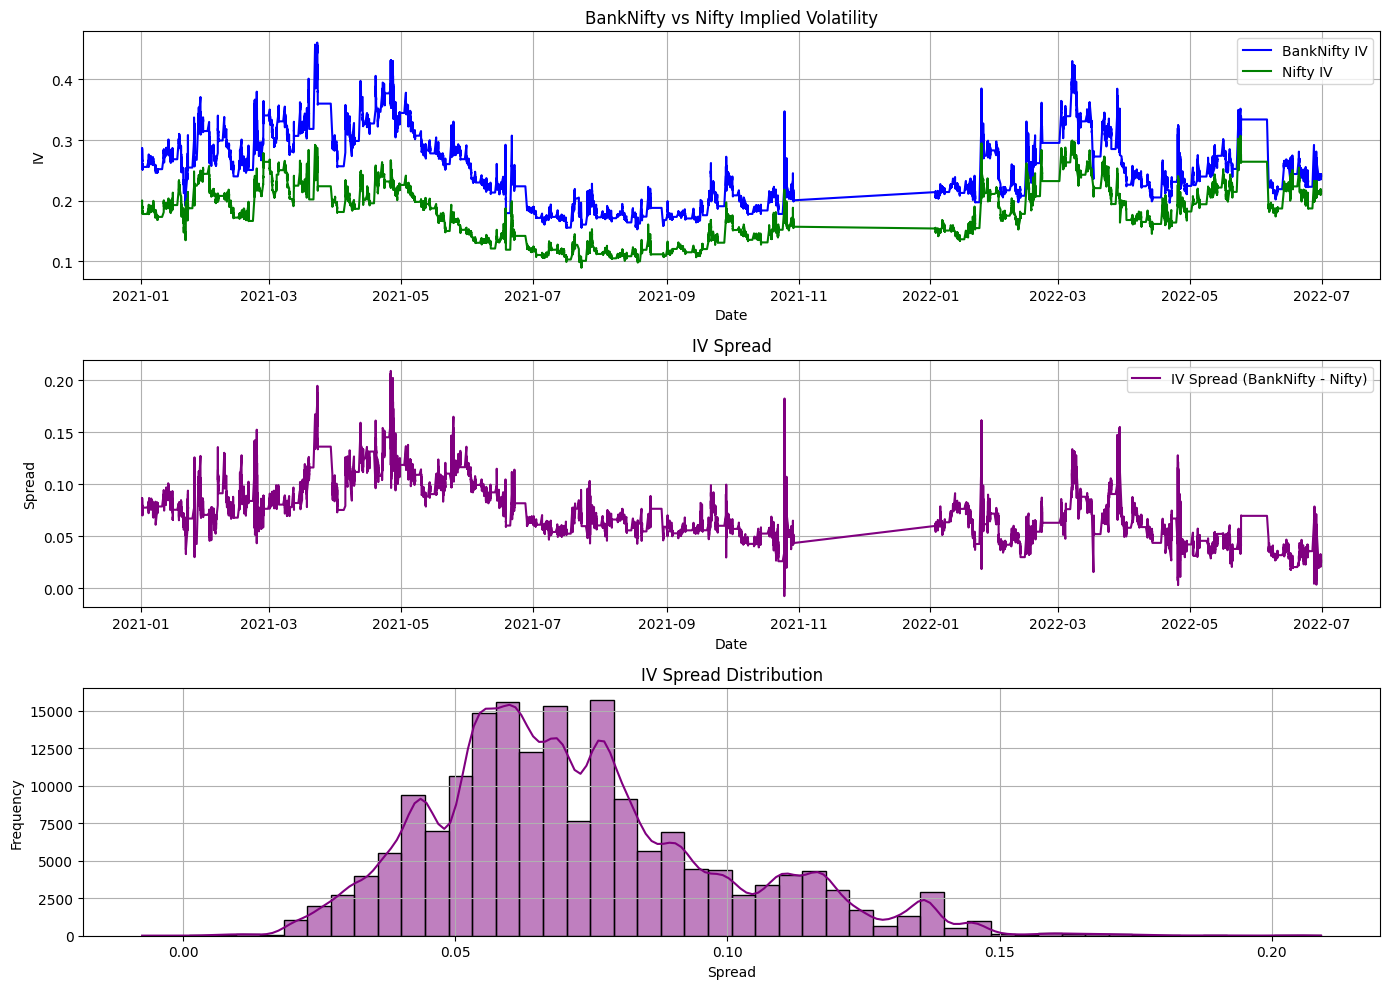

In [ ]:
plot_data(df)

In [ ]:
def percentile_model(data, percentile_threshold=75, lookback=252):
    """
    Implement percentile-based strategy.
    - percentile_threshold: Upper percentile to trigger signal.
    - lookback: Rolling window for percentile calculation.
    """
    if data is None:
        raise ValueError("No data provided.")

    # Create a copy to avoid modifying original data
    data = data.copy()

    # Calculate rolling percentile of IV spread
    data['percentile'] = data['iv_spread'].rolling(window=lookback, min_periods=50).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False
    )

    # Generate signals: Buy when spread exceeds percentile threshold
    data['signal'] = np.where(data['percentile'] > percentile_threshold, 1, 0)

    # Calculate PnL: Spread * (tte)^0.7
    data['pnl'] = data['signal'] * data['iv_spread'] * (data['tte'] ** 0.7)

    # Cumulative PnL
    data['cum_pnl'] = data['pnl'].cumsum()

    return data[['iv_spread', 'percentile', 'signal', 'pnl', 'cum_pnl']]

In [ ]:
print(percentile_model(df))

                     iv_spread  percentile  signal       pnl       cum_pnl
time                                                                      
2021-01-01 09:15:00   0.086329         NaN       0  0.000000      0.000000
2021-01-01 09:16:00   0.084948         NaN       0  0.000000      0.000000
2021-01-01 09:17:00   0.084229         NaN       0  0.000000      0.000000
2021-01-01 09:18:00   0.086244         NaN       0  0.000000      0.000000
2021-01-01 09:19:00   0.086588         NaN       0  0.000000      0.000000
...                        ...         ...     ...       ...           ...
2022-06-30 15:26:00   0.025943   63.095238       0  0.000000  19384.501456
2022-06-30 15:27:00   0.024317   32.142857       0  0.000000  19384.501456
2022-06-30 15:28:00   0.025321   51.190476       0  0.000000  19384.501456
2022-06-30 15:29:00   0.026971   88.492063       1  0.277912  19384.779368
2022-06-30 15:30:00   0.025827   61.507937       0  0.000000  19384.779368

[180856 rows x 5 columns

In [ ]:
def optimize_percentile_threshold(data, percentile_range=np.arange(50, 95, 5), lookback=252):
    """
    Find the best percentile threshold based on cumulative PnL.
    - percentile_range: Range of percentiles to test.
    - lookback: Rolling window for percentile calculation.
    """
    if data is None:
        raise ValueError("No data provided.")

    results = []

    for percentile in percentile_range:
        # Run percentile model
        temp_data = percentile_model(data, percentile_threshold=percentile, lookback=lookback)

        # Calculate performance metrics
        total_pnl = temp_data['cum_pnl'].iloc[-1]
        sharpe_ratio = temp_data['pnl'].mean() / temp_data['pnl'].std() * np.sqrt(252) if temp_data['pnl'].std() != 0 else 0
        num_trades = temp_data['signal'].sum()

        results.append({
            'percentile': percentile,
            'total_pnl': total_pnl,
            'sharpe_ratio': sharpe_ratio,
            'num_trades': num_trades
        })

    # Convert to DataFrame
    results_df = pd.DataFrame(results)

    # Find best percentile
    best_result = results_df.loc[results_df['total_pnl'].idxmax()]

    # Print results
    print("Optimization Results:")
    print(results_df)
    print("\nBest Percentile Threshold:")
    print(best_result)

    # Plot results
    plt.figure(figsize=(10, 6))
    plt.plot(results_df['percentile'], results_df['total_pnl'], marker='o', color='purple')
    plt.title('Total PnL vs Percentile Threshold')
    plt.xlabel('Percentile Threshold')
    plt.ylabel('Total PnL')
    plt.grid(True)
    plt.show()

    return results_df, best_result

Optimization Results:
   percentile     total_pnl  sharpe_ratio  num_trades
0          50  52226.427255     14.287245      110969
1          55  30898.288706      9.021132       57448
2          60  27976.272873      8.436991       51925
3          65  25323.172861      7.890671       46817
4          70  22460.452242      7.309204       41458
5          75  19384.779368      6.682759       35830
6          80  16476.254323      6.068359       30426
7          85  13238.664121      5.379773       24494
8          90  10038.896146      4.611016       18475

Best Percentile Threshold:
percentile          50.000000
total_pnl        52226.427255
sharpe_ratio        14.287245
num_trades      110969.000000
Name: 0, dtype: float64


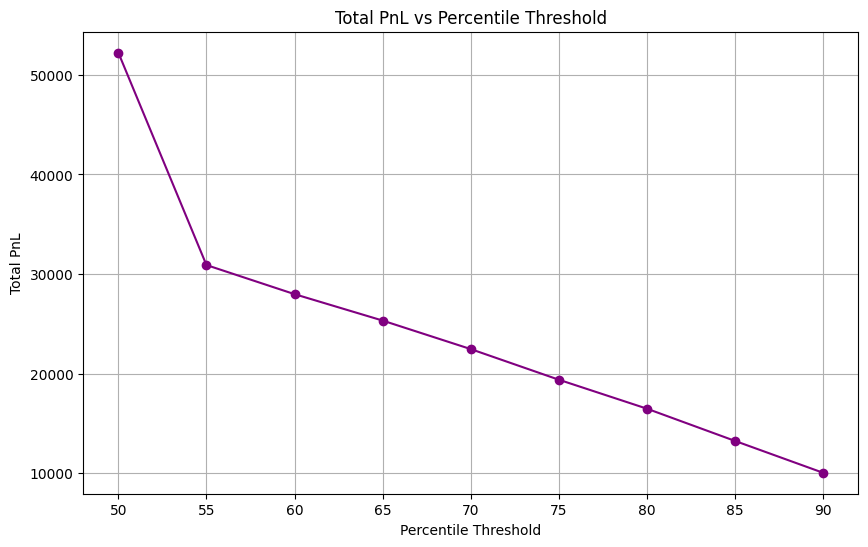

In [ ]:
results_df, best_result = optimize_percentile_threshold(df)

In [ ]:
import numpy as np

def calculate_metrics(data, lookback=90):
    """
    Calculate z-scores and percentile ranks for IV spread.
    """
    if data is None:
        raise ValueError("No data provided.")

    data = data.copy()
    min_periods = max(30, int(lookback * 0.1))

    # Z-score
    data['spread_mean'] = data['iv_spread'].rolling(window=lookback, min_periods=min_periods).mean()
    data['spread_std'] = data['iv_spread'].rolling(window=lookback, min_periods=min_periods).std()
    data['z_score'] = (data['iv_spread'] - data['spread_mean']) / data['spread_std']

    # Percentile
    data['percentile'] = data['iv_spread'].rolling(window=lookback, min_periods=min_periods).apply(
        lambda x: pd.Series(x).rank(pct=True).iloc[-1] * 100, raw=False
    )

    return data

In [ ]:
df=calculate_metrics(df)

In [ ]:
print(df)

                     banknifty     nifty  tte  iv_spread  spread_mean  \
time                                                                    
2021-01-01 09:15:00   0.286058  0.199729   27   0.086329          NaN   
2021-01-01 09:16:00   0.285381  0.200433   27   0.084948          NaN   
2021-01-01 09:17:00   0.284233  0.200004   27   0.084229          NaN   
2021-01-01 09:18:00   0.286104  0.199860   27   0.086244          NaN   
2021-01-01 09:19:00   0.285539  0.198951   27   0.086588          NaN   
...                        ...       ...  ...        ...          ...   
2022-06-30 15:26:00   0.240701  0.214758   28   0.025943     0.025667   
2022-06-30 15:27:00   0.240875  0.216558   28   0.024317     0.025654   
2022-06-30 15:28:00   0.242115  0.216794   28   0.025321     0.025645   
2022-06-30 15:29:00   0.243426  0.216455   28   0.026971     0.025649   
2022-06-30 15:30:00   0.241907  0.216081   28   0.025827     0.025667   

                     spread_std   z_score  percent

In [ ]:
def generate_signals(data, percentile_threshold=75, z_entry=1.3, z_exit=0.0,
                     min_holding=30, max_holding=375*5):
    """
    Generate signals based on both z-score and percentile conditions.
    """
    if data is None:
        raise ValueError("No data provided.")

    df = data.copy()
    df['signal'] = 0
    df['entry_time'] = pd.NaT
    df['holding_period'] = 0.0

    in_trade = False
    entry_z = 0
    holding_counter = 0

    for i in range(1, len(df)):
        current_time = df.index[i]
        current_z = df.at[current_time, 'z_score']
        current_percentile = df.at[current_time, 'percentile']

        if in_trade:
            holding_counter += 1
            df.at[current_time, 'holding_period'] = holding_counter

            exit_due_to_z = abs(current_z) <= z_exit
            exit_due_to_cross = (entry_z > 0 and current_z <= 0) or (entry_z < 0 and current_z >= 0)
            exit_due_to_max = holding_counter >= max_holding

            if holding_counter >= min_holding and (exit_due_to_z or exit_due_to_cross or exit_due_to_max):
                in_trade = False
                entry_z = 0
                holding_counter = 0
                continue
            else:
                df.at[current_time, 'signal'] = np.sign(entry_z) * -1
                continue

        if current_z >= z_entry or current_percentile >= percentile_threshold:
            df.at[current_time, 'signal'] = -1  # Short spread
            df.at[current_time, 'entry_time'] = current_time
            entry_z = current_z
            in_trade = True
            holding_counter = 0
        elif current_z <= -z_entry or current_percentile <= (100 - percentile_threshold):
            df.at[current_time, 'signal'] = 1  # Long spread
            df.at[current_time, 'entry_time'] = current_time
            entry_z = current_z
            in_trade = True
            holding_counter = 0

    df['signal'] = df['signal'].replace(to_replace=0, method='ffill').fillna(0)
    return df

In [ ]:
df=generate_signals(df)
print(df)

                     banknifty     nifty  tte  iv_spread  spread_mean  \
time                                                                    
2021-01-01 09:15:00   0.286058  0.199729   27   0.086329          NaN   
2021-01-01 09:16:00   0.285381  0.200433   27   0.084948          NaN   
2021-01-01 09:17:00   0.284233  0.200004   27   0.084229          NaN   
2021-01-01 09:18:00   0.286104  0.199860   27   0.086244          NaN   
2021-01-01 09:19:00   0.285539  0.198951   27   0.086588          NaN   
...                        ...       ...  ...        ...          ...   
2022-06-30 15:26:00   0.240701  0.214758   28   0.025943     0.025667   
2022-06-30 15:27:00   0.240875  0.216558   28   0.024317     0.025654   
2022-06-30 15:28:00   0.242115  0.216794   28   0.025321     0.025645   
2022-06-30 15:29:00   0.243426  0.216455   28   0.026971     0.025649   
2022-06-30 15:30:00   0.241907  0.216081   28   0.025827     0.025667   

                     spread_std   z_score  percent

<ipython-input-17-fc7839e6aeba>:53: FutureWarning: The 'method' keyword in Series.replace is deprecated and will be removed in a future version.
  df['signal'] = df['signal'].replace(to_replace=0, method='ffill').fillna(0)


In [ ]:
def calculate_pnl(data, tte_exponent=0.7):
    """
    Calculate PnL using Spread * (tte)^0.7.
    """
    if data is None:
        raise ValueError("No data provided.")

    data = data.copy()
    data['daily_pl'] = (
        data['signal'].shift(1) *
        data['iv_spread'] *
        (data['tte'] ** tte_exponent)
    )
    data['cumulative_pl'] = data['daily_pl'].cumsum()
    return data

In [ ]:
df=calculate_pnl(df)
print(df)

                     banknifty     nifty  tte  iv_spread  spread_mean  \
time                                                                    
2021-01-01 09:15:00   0.286058  0.199729   27   0.086329          NaN   
2021-01-01 09:16:00   0.285381  0.200433   27   0.084948          NaN   
2021-01-01 09:17:00   0.284233  0.200004   27   0.084229          NaN   
2021-01-01 09:18:00   0.286104  0.199860   27   0.086244          NaN   
2021-01-01 09:19:00   0.285539  0.198951   27   0.086588          NaN   
...                        ...       ...  ...        ...          ...   
2022-06-30 15:26:00   0.240701  0.214758   28   0.025943     0.025667   
2022-06-30 15:27:00   0.240875  0.216558   28   0.024317     0.025654   
2022-06-30 15:28:00   0.242115  0.216794   28   0.025321     0.025645   
2022-06-30 15:29:00   0.243426  0.216455   28   0.026971     0.025649   
2022-06-30 15:30:00   0.241907  0.216081   28   0.025827     0.025667   

                     spread_std   z_score  percent

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_results(data, z_entry=1.3, z_exit=0.0, percentile_threshold=75):
    """
    Plot IV spread, z-score, percentile, and cumulative PnL.
    """
    if data is None:
        raise ValueError("No data provided.")

    fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 16))

    # IV Spread
    ax1.plot(data['iv_spread'], label='IV Spread', alpha=0.7)
    entries = data[data['signal'].diff().abs() > 0]
    colors = ['g' if s == 1 else 'r' for s in entries['signal']]
    ax1.scatter(entries.index, entries['iv_spread'], c=colors, s=50, label='Entries')
    ax1.set_title('IV Spread with Trade Entries')
    ax1.set_xlabel('Date')
    ax1.set_ylabel('Spread')
    ax1.legend()
    ax1.grid(True)

    # Z-Score
    ax2.plot(data['z_score'], label='Z-Score', alpha=0.7)
    ax2.axhline(z_entry, color='r', linestyle='--', alpha=0.3, label='Entry/Exit Thresholds')
    ax2.axhline(-z_entry, color='r', linestyle='--', alpha=0.3)
    ax2.axhline(z_exit, color='g', linestyle='--', alpha=0.3)
    ax2.axhline(-z_exit, color='g', linestyle='--', alpha=0.3)
    ax2.set_title('Z-Score with Trading Bands')
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Z-Score')
    ax2.legend()
    ax2.grid(True)

    # Percentile
    ax3.plot(data['percentile'], label='Percentile Rank', alpha=0.7)
    ax3.axhline(percentile_threshold, color='r', linestyle='--', alpha=0.3, label='Percentile Thresholds')
    ax3.axhline(100 - percentile_threshold, color='r', linestyle='--', alpha=0.3)
    ax3.set_title('Percentile Rank with Thresholds')
    ax3.set_xlabel('Date')
    ax3.set_ylabel('Percentile')
    ax3.legend()
    ax3.grid(True)

    # Cumulative PnL
    ax4.plot(data['cumulative_pl'], label='Cumulative PnL', color='purple')
    ax4.axhline(0, color='black', linestyle='--')
    ax4.set_title('Cumulative PnL')
    ax4.set_xlabel('Date')
    ax4.set_ylabel('PnL')
    ax4.legend()
    ax4.grid(True)

    plt.tight_layout()
    plt.show()

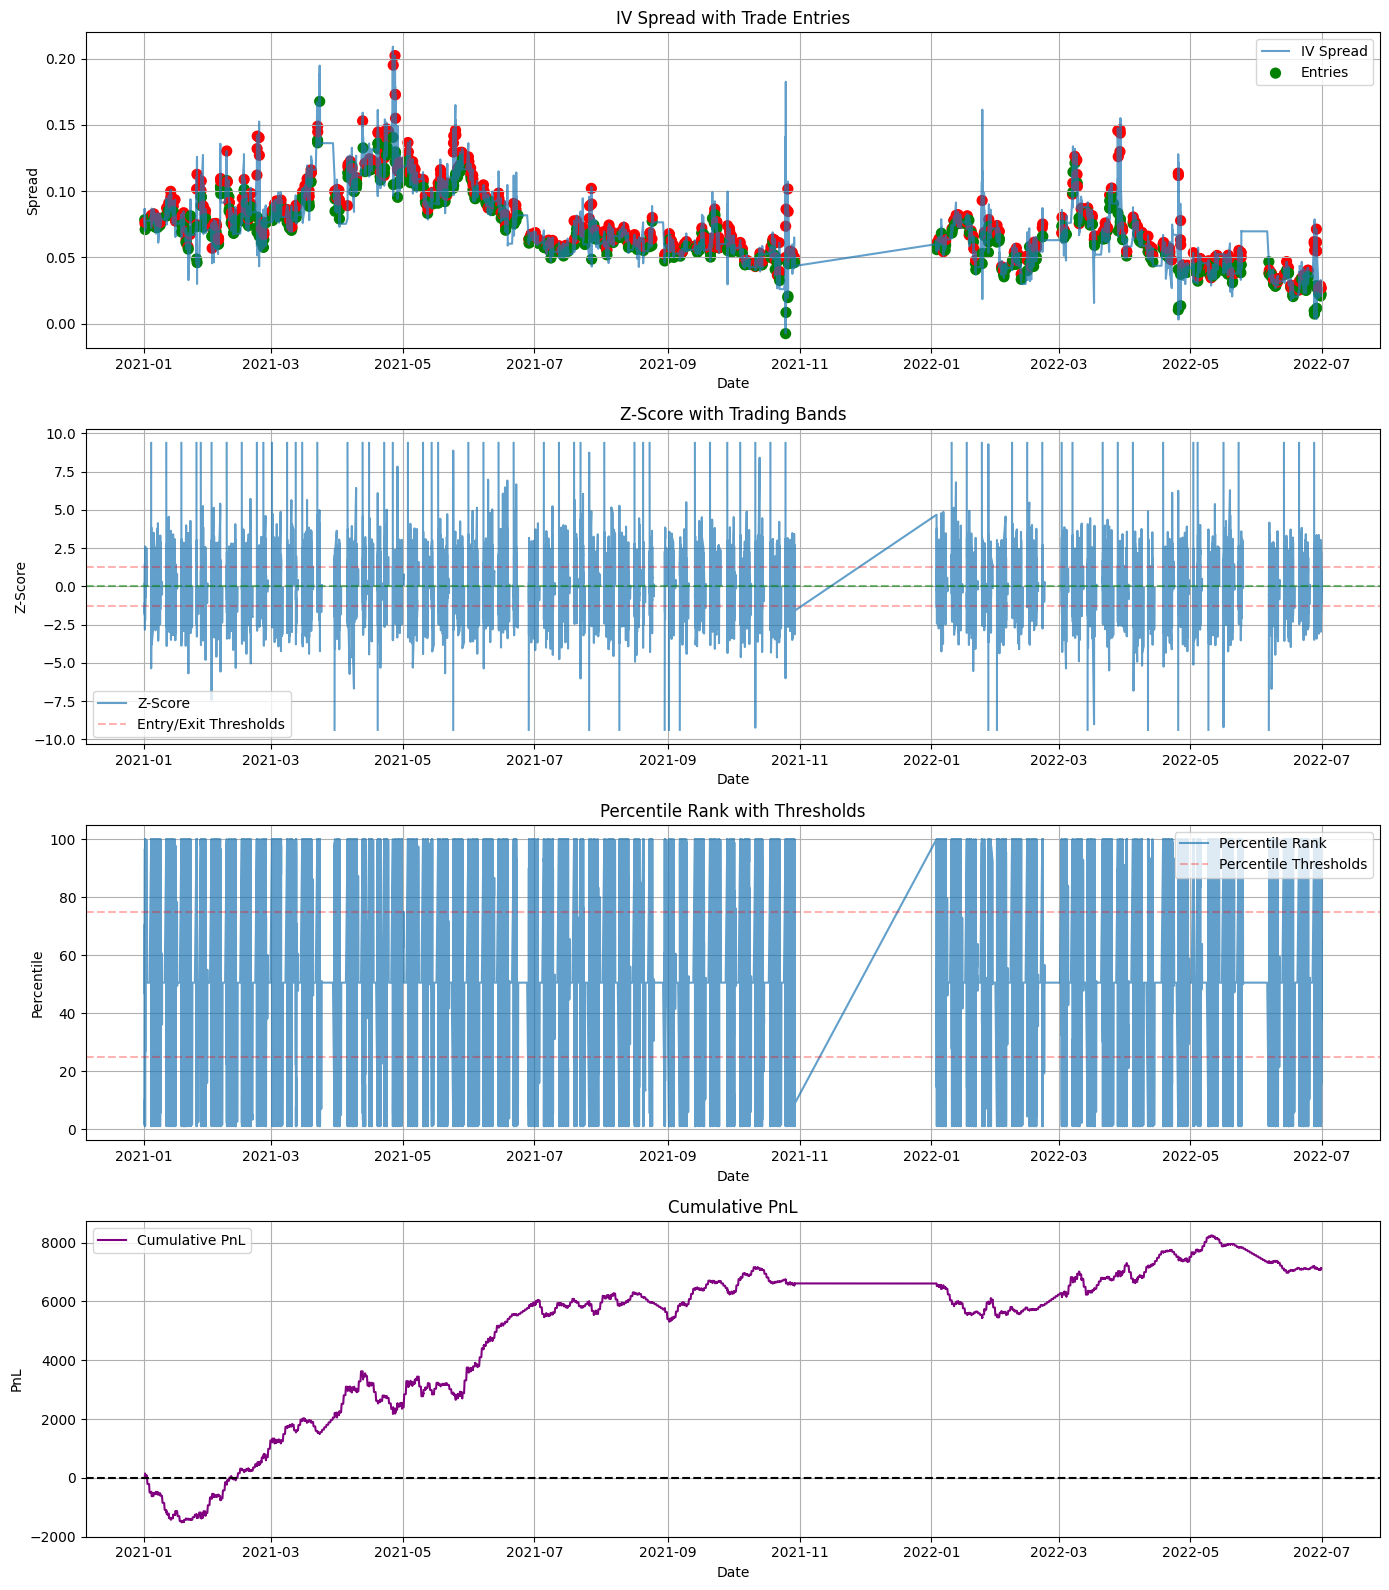

In [ ]:
plot_results(df)